
  
  # 📘 Introduction 

This notebook works with a numerical regression dataset used for machine learning practice.
The dataset is clean, simple, and suitable for Kaggle-style analysis.

# 📊 About the Dataset

This is a tabular numerical dataset

* All columns numeric 

* Features are anonymized (f_00 to f_28)

* One column is an ID column (not useful for modeling)

* No missing or null values

* Data is clearing 

* No categorical or text data

## 🧠 What This Dataset Is Used For

* Regression problems

* Predicting a continuous numeric value

* EDA and ML models

* Kaggle competition–style workflows

# 🤖 Modeling Plan

* Strat with Train Test Split
* Linear Regression (baseline)

* Apply Decision Tree Regressor

* Use Random Forest Regressor

* Compare model performance

* Select the best performing model

# Import Library 

In [1]:
#==========================Data Analysis==========================

import pandas as pd 
import numpy as np

#==========================Data Visulaization=====================

import matplotlib.pyplot as plt 
import seaborn as sns

#=========================Feature Engineering=====================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

#========================Remove Warning===========================

import warnings
warnings.filterwarnings("ignore")

# =======================Visualization settings===================

plt.rcParams["figure.figsize"] = (10, 6)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_style("darkgrid", {
    "grid.color": "gray",
    "grid.linestyle": "--",
    "grid.linewidth": 0.5
})
print("All libraries imported successfully")

All libraries imported successfully


# Exploratory Data Analysis(EDA)

In [2]:
#==============================Read_Data=====================================

train = pd.read_csv("/kaggle/input/sch2-reg-2026-d5-2/data.csv")
test = pd.read_csv("/kaggle/input/sch2-reg-2026-d5-2/sample_submission.csv")
display(test)
#==============================First_5_Row===================================

print("="*30)
print("\033[1m" + "First 5 Row" + "\033[0m")
print("="*30)
print(" ")
display(train.head())

#==============================Last_5_Row====================================

print(" ")
print("="*30)
print("\033[1m" + "Last 5 Row" + "\033[0m")
print("="*30)
print(" ")
display(train.tail())

#==============================Describe Data=================================

print(" ")
print("="*30)
print("\033[1m" + "Described Data" + "\033[0m")
print("="*30)
print(" ")
display(train.describe())

#=============================Information Data================================

print(" ")
print("="*30)
print("\033[1m" + "Information From Dataset" + "\033[0m")
print("="*30)
print(" ")
display(train.info())
#===============================Data_types====================================

print(" ")
print("="*30)
print("\033[1m" + "Data_Types From Dataset" + "\033[0m")
print("="*30)
print(" ")
var_1 = pd.DataFrame(train.dtypes, columns = ["Data_Types"])
display(var_1)
print(" ")
print("This is Dataset dtype.")

#===================================Columns====================================

print(" ")
print("="*30)
print("\033[1m" + "Columns Name" + "\033[0m")
print("="*30)
print(" ")
var_2 = pd.DataFrame(train.columns, columns = ["Columns Name"])
display(var_2)
print(" ")
print("This is Columns Name From Dataset.")

#==================================Missing vaue=================================

print(" ")
print("="*30)
print("\033[1m" + "Missing Values" + "\033[0m")
print("="*30)
print(" ")
display(train.isnull().sum())
print(" ")
print("Dataset is already clean.")

#====================================Duplicated values==========================

print(" ")
print("="*30)
print("\033[1m" + "Missing Values"  + "\033[0m")
print("="*30)
print(" ")
display(train.duplicated())

#===============================================================================#

,Id,Predicted
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0
...,...,...
97995,97995,0
97996,97996,0
97997,97997,0
97998,97998,0


First 5 Row
 


,id,f_00,f_01,f_02,f_03,f_04,f_05,f_06,f_07,f_08,...,f_19,f_20,f_21,f_22,f_23,f_24,f_25,f_26,f_27,f_28
0,0,-0.389420,-0.912791,0.648951,0.589045,-0.830817,0.733624,2.258560,2,13,...,-0.478412,-0.757002,-0.763635,-1.090369,1.142641,-0.884274,1.137896,1.309073,1.463002,0.813527
1,1,-0.689249,-0.453954,0.654175,0.995248,-1.653020,0.863810,-0.090651,2,3,...,-0.428791,-0.089908,-1.784204,-0.839474,0.459685,1.759412,-0.275422,-0.852168,0.562457,-2.680541
2,2,0.809079,0.324568,-1.170602,-0.624491,0.105448,0.783948,1.988301,5,11,...,-0.413534,-1.602377,1.190984,3.267116,-0.088322,-2.168635,-0.974989,1.335763,-1.110655,-3.630723
3,3,-0.500923,0.229049,0.264109,0.231520,0.415012,-1.221269,0.138850,6,2,...,0.619283,1.287801,0.532837,1.036631,-2.041828,1.440490,-1.900191,-0.630771,-0.050641,0.238333
4,4,-0.671268,-1.039533,-0.270155,-1.830264,-0.290108,-1.852809,0.781898,8,7,...,-1.628830,-0.434948,0.322505,0.284326,-2.438365,1.473930,-1.044684,1.602686,-0.405263,-1.987263


 
Last 5 Row
 


,id,f_00,f_01,f_02,f_03,f_04,f_05,f_06,f_07,f_08,...,f_19,f_20,f_21,f_22,f_23,f_24,f_25,f_26,f_27,f_28
97995,97995,0.237591,1.657034,-0.689282,0.313710,-0.299039,0.329139,1.607378,5,7,...,-0.290116,-0.258141,-0.973640,1.369508,0.391055,2.152426,-0.208944,-1.475403,0.298448,0.445039
97996,97996,0.322696,0.710411,0.562625,-1.321713,-0.357708,0.182024,0.178558,3,9,...,0.117687,1.388242,0.342400,1.680537,-0.860409,0.579165,1.162692,0.134994,0.994666,0.727642
97997,97997,-0.249364,-0.459545,1.886122,-1.340310,0.195029,-0.559520,-0.379767,8,9,...,-0.850223,-1.787648,-1.268115,-1.508330,1.945622,1.503645,0.194968,2.142693,1.646042,0.641466
97998,97998,0.311408,2.185237,0.761367,0.436723,0.464967,0.062321,-0.334025,1,8,...,-0.010839,1.118906,1.565765,0.358480,0.547615,1.224439,-0.537998,-1.610954,-0.616227,-0.066211
97999,97999,0.755170,0.567483,1.456767,-0.579071,-0.048474,-1.206240,0.784305,0,11,...,1.180805,-0.925705,-1.368680,-2.465425,1.453582,-1.685122,0.129689,-0.970897,1.404988,-0.711098


...

,Columns Name
0,id
1,f_00
2,f_01
3,f_02
4,f_03
5,f_04
6,f_05
7,f_06
8,f_07
9,f_08


 
This is Columns Name From Dataset.
 
Missing Values
 


id      0
f_00    0
f_01    0
f_02    0
f_03    0
f_04    0
f_05    0
f_06    0
f_07    0
f_08    0
f_09    0
f_10    0
f_11    0
f_12    0
f_13    0
f_14    0
f_15    0
f_16    0
f_17    0
f_18    0
f_19    0
f_20    0
f_21    0
f_22    0
f_23    0
f_24    0
f_25    0
f_26    0
f_27    0
f_28    0
dtype: int64

 
Dataset is already clean.
 
Missing Values
 


0        False
1        False
2        False
3        False
4        False
         ...  
97995    False
97996    False
97997    False
97998    False
97999    False
Length: 98000, dtype: bool

# Data Visulaization 


* Histogram

* Box Plot

* Correlation Heatmap

* Actual vs Predicted

* Residual Plot

#  Histogram From Dataset


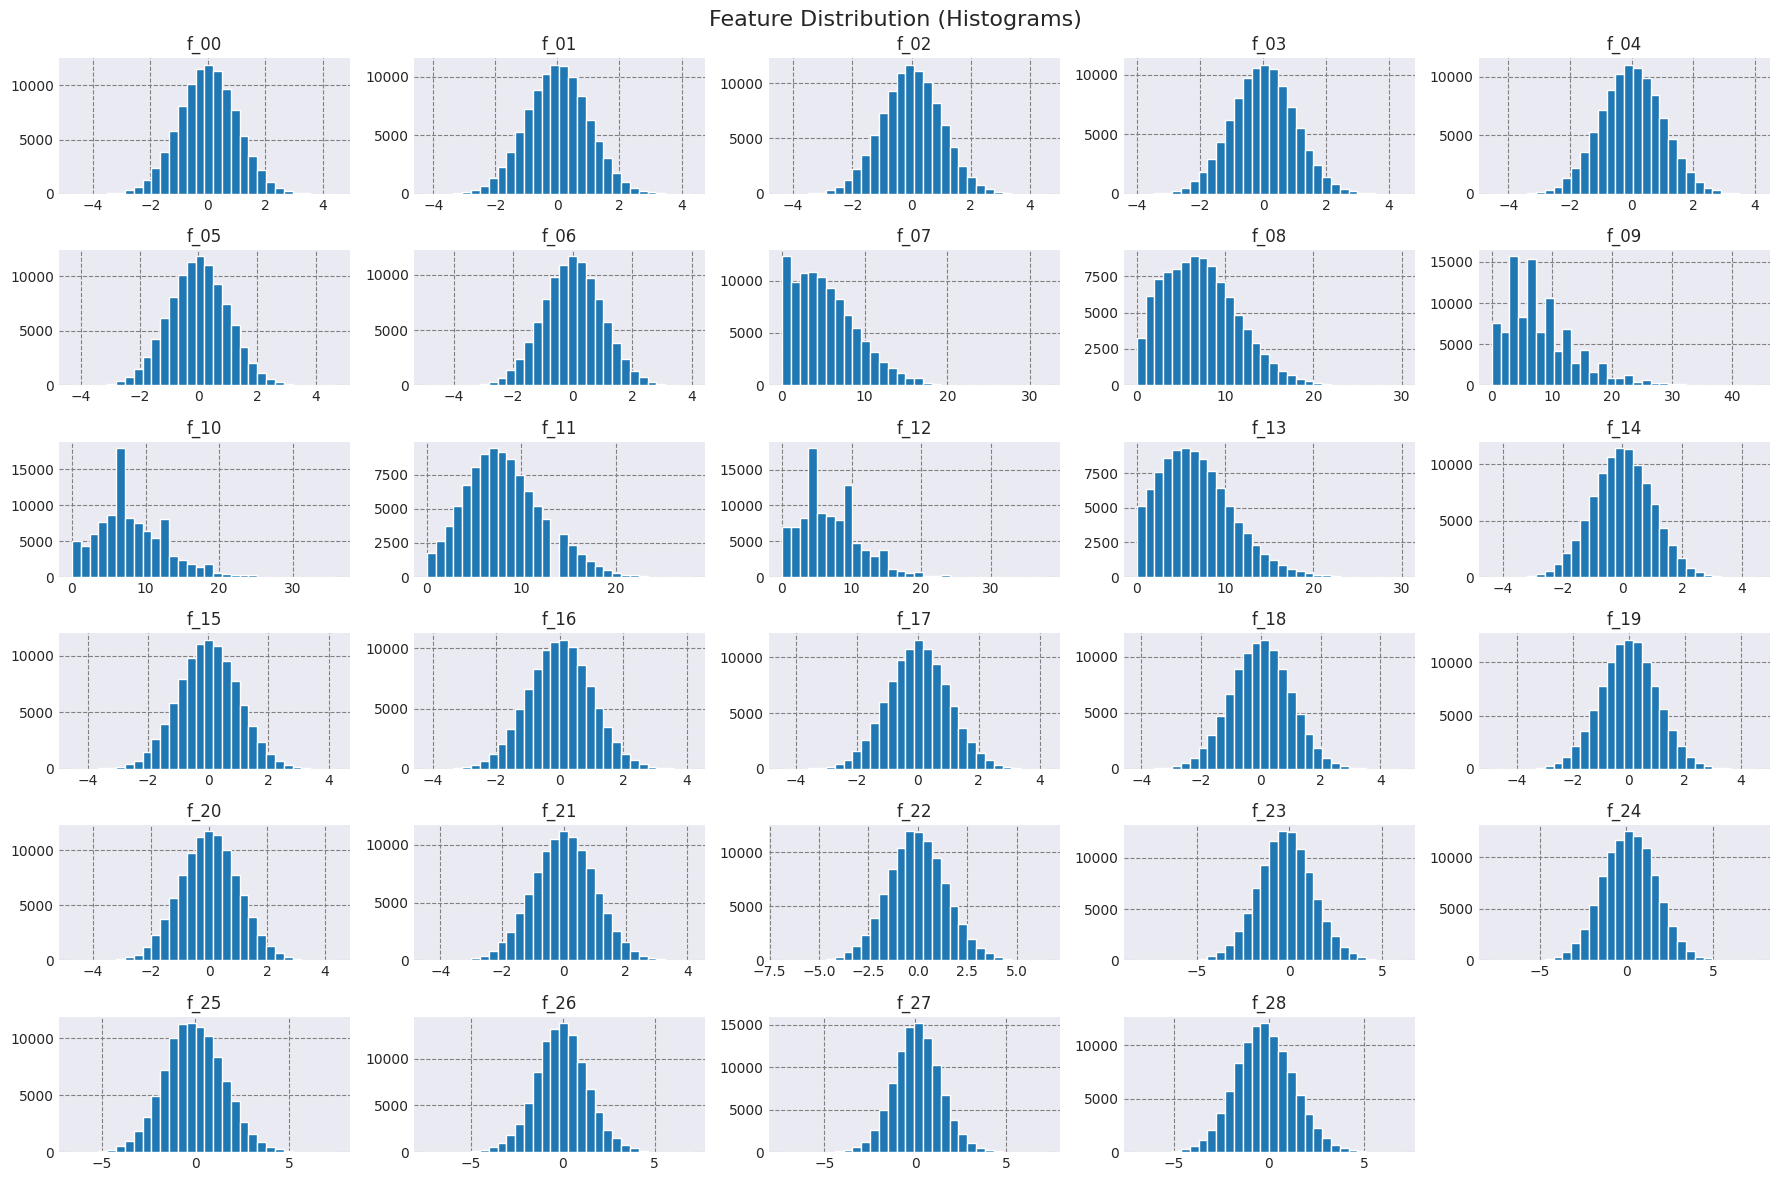

In [3]:
# Select only feature columns (exclude id)
features = train.drop(columns=['id'])

# Plot histograms
features.hist(
    figsize=(18, 12),
    bins=30,
    
)
plt.suptitle("Feature Distribution (Histograms)", fontsize=16)
plt.tight_layout()
plt.show()


# Insight 

The histograms show that most features follow different distributions, indicating variability and potential non-linear relationships suitable for tree-based regression models.

# 📦 Box Plot 
### ✅ Purpose

* Detect outliers

* Check data spread

* Compare feature ranges

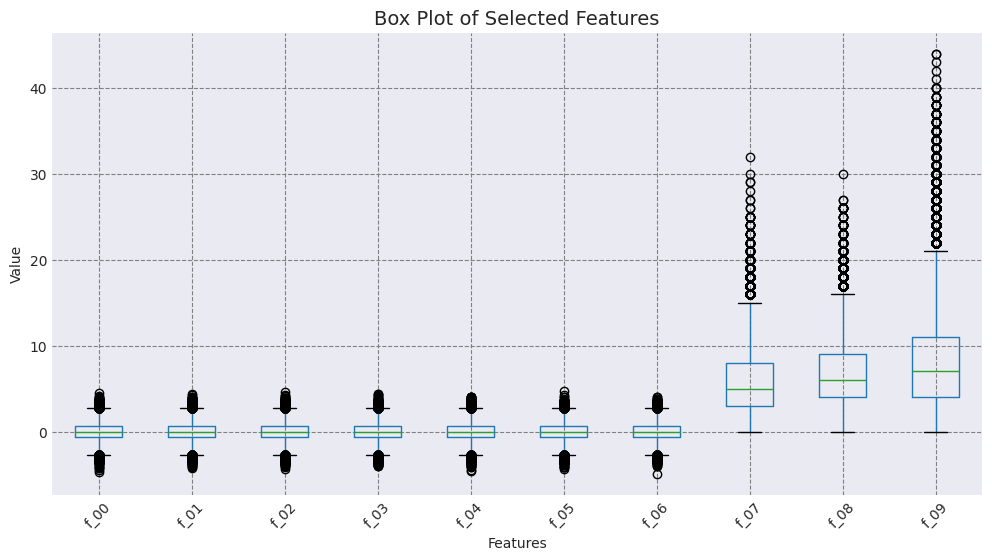

In [4]:
feature_cols = [col for col in train.columns if col != 'id']

# Plot boxplots for first 6 features (avoid clutter)
plt.figure(figsize=(12, 6))
train[feature_cols[:10]].boxplot()

plt.title("Box Plot of Selected Features", fontsize=14)
plt.xlabel("Features")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.show()

# Start Algorithm

* Train Test split 
* Standard Scaler
* LinearRegression
* DecisionTreeRegressor
* RandomForestRegressor
* R2_Score
* Mean_Squared_Error



### Thanks for Reading — See You in the Next Notebook 🙃